# Part B: Predictive Modeling

In this section, the cleaned Titanic dataset is used to build machine learning models for predicting passenger survival. A stratified train-test split is performed to preserve the class distribution.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
X = df.drop(columns=["survived", "alive"])
y = df["survived"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object","category","bool"]).columns

In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Task 7: Stratified Train-Test Split

The cleaned Titanic dataset is divided into training and testing sets using a stratified split. Stratification ensures that the class distribution of the target variable (survived) remains approximately the same in both the training and testing datasets, leading to a fair and reliable model evaluation.

In [8]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

In [9]:
X = df.drop("survived", axis=1)

y = df["survived"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
X = df.drop(
    columns=[
        "survived",
        "alive"
    ]
)

y = df["survived"]

### Interpretation

A stratified train-test split preserves the original class distribution in both the training and testing datasets. This is important because the target variable (Survived) is imbalanced.

# Task 8: Data Preprocessing

The preprocessing pipeline performs:

- Missing value imputation
- One-Hot Encoding
- Feature Scaling

All preprocessing is fitted only on the training data.

In [12]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object","category","bool"]).columns

In [13]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [14]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [15]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Interpretation

The preprocessing pipeline is fitted only on the training data to prevent data leakage. The same fitted transformations are applied to the test data.

# Task 9: Train Machine Learning Models

Three classifiers are trained:

- Logistic Regression
- Decision Tree
- Random Forest

In [16]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

In [17]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['pclass','sex','age',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

In [18]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['pclass','sex','age',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

In [19]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['pclass','sex','age',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

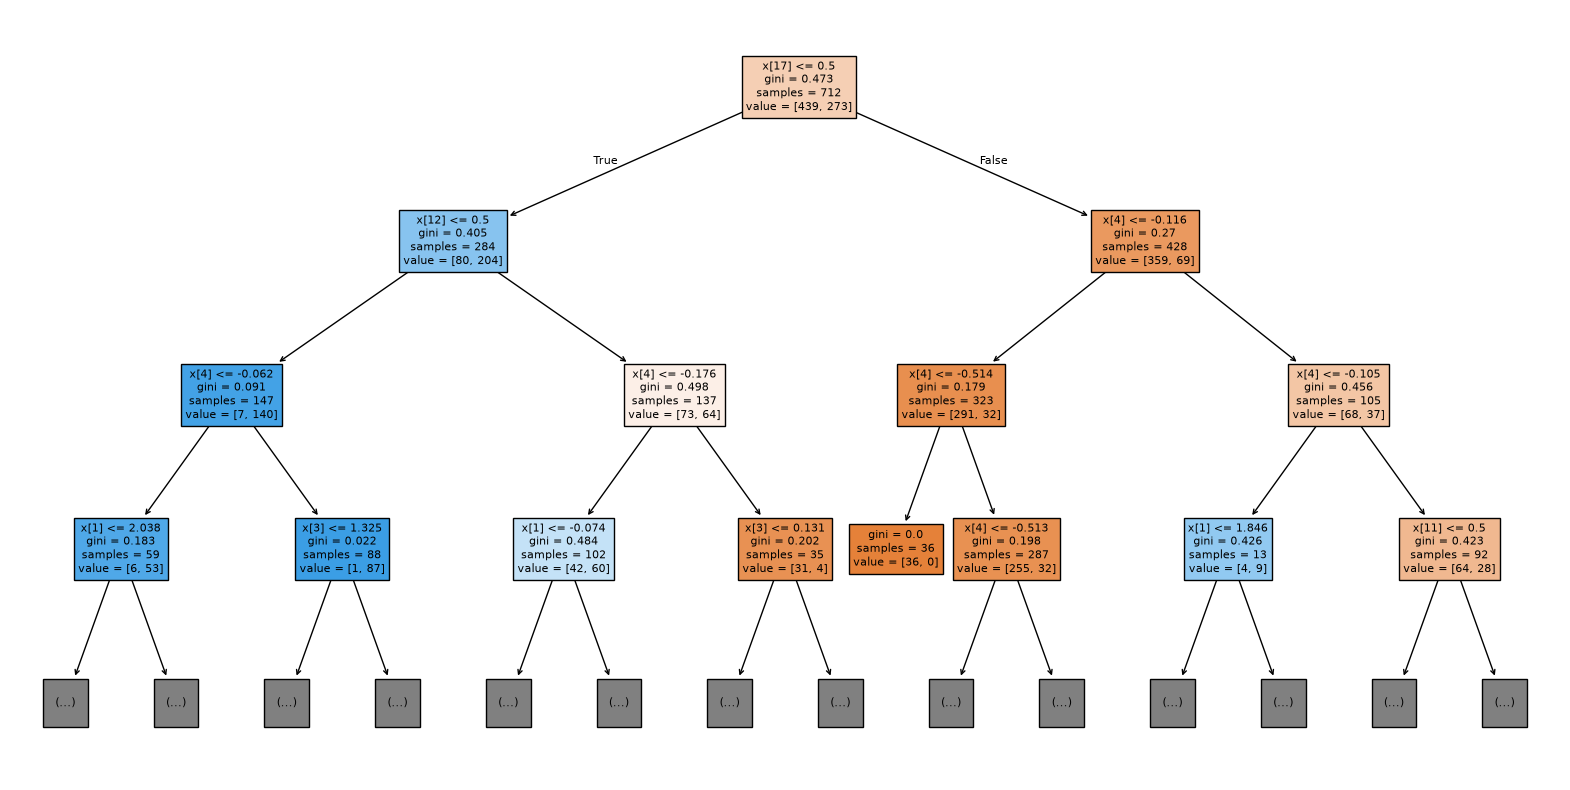

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    tree_model.named_steps["classifier"],
    filled=True,
    max_depth=3
)

plt.savefig("plots/decision_tree.png")

plt.show()

### Interpretation

The Decision Tree provides a visual representation of how the model makes predictions using different passenger features.

# Task 10: Model Evaluation

The three classifiers are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [22]:
def evaluate(model,name):

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    print("\n",name)

    print("Accuracy :",accuracy_score(y_test,pred))

    print("Precision :",precision_score(y_test,pred))

    print("Recall :",recall_score(y_test,pred))

    print("F1 :",f1_score(y_test,pred))

    print("ROC AUC :",roc_auc_score(y_test,prob))

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test,pred))

In [23]:
evaluate(log_model,"Logistic Regression")

evaluate(tree_model,"Decision Tree")

evaluate(rf_model,"Random Forest")


 Logistic Regression
Accuracy : 0.8324022346368715
Precision : 0.8095238095238095
Recall : 0.7391304347826086
F1 : 0.7727272727272727
ROC AUC : 0.8686429512516469

Confusion Matrix
[[98 12]
 [18 51]]

 Decision Tree
Accuracy : 0.8044692737430168
Precision : 0.75
Recall : 0.7391304347826086
F1 : 0.7445255474452555
ROC AUC : 0.7905797101449276

Confusion Matrix
[[93 17]
 [18 51]]

 Random Forest
Accuracy : 0.8268156424581006
Precision : 0.7878787878787878
Recall : 0.7536231884057971
F1 : 0.7703703703703704
ROC AUC : 0.8362977602108037

Confusion Matrix
[[96 14]
 [17 52]]


In [24]:
results = []

models = {
    "Logistic Regression":log_model,
    "Decision Tree":tree_model,
    "Random Forest":rf_model
}

for name,model in models.items():

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.832402,0.809524,0.739130,0.772727,0.868643
1,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.790580
2,Random Forest,0.826816,0.787879,0.753623,0.770370,0.836298


### Interpretation

The three models were evaluated on the same test set. The comparison table summarizes their performance across multiple evaluation metrics. The best-performing model will be selected for further tuning and deployment.

# Task 11: Imbalance Handling Comparison

The Titanic dataset is slightly imbalanced, with more non-survivors than survivors. In this task, three approaches are compared:

1. Baseline Random Forest
2. Random Forest with class_weight='balanced'
3. Random Forest with SMOTE

The models are evaluated using Accuracy, Precision, Recall, and F1-Score.

survived
0    549
1    342
Name: count, dtype: int64


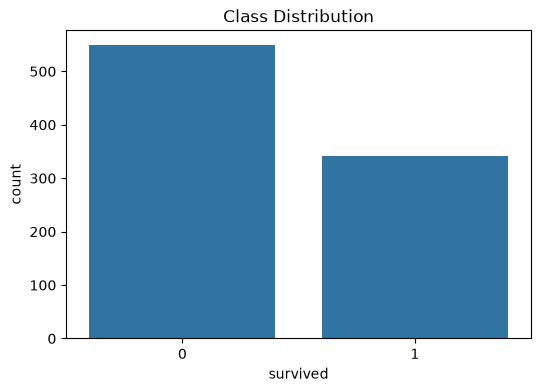

In [25]:
print(df["survived"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="survived", data=df)
plt.title("Class Distribution")
plt.savefig("plots/class_distribution.png")
plt.show()

### Interpretation

The dataset contains more non-survived passengers than survived passengers. Therefore, imbalance handling techniques are compared to improve prediction performance for the minority class.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_pred = rf_model.predict(X_test)

print("Baseline Random Forest")

print("Accuracy :", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall   :", recall_score(y_test, baseline_pred))
print("F1 Score :", f1_score(y_test, baseline_pred))

Baseline Random Forest
Accuracy : 0.8268156424581006
Precision: 0.7878787878787878
Recall   : 0.7536231884057971
F1 Score : 0.7703703703703704


In [27]:
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)

print("Balanced Random Forest")

print("Accuracy :", accuracy_score(y_test, balanced_pred))
print("Precision:", precision_score(y_test, balanced_pred))
print("Recall   :", recall_score(y_test, balanced_pred))
print("F1 Score :", f1_score(y_test, balanced_pred))

Balanced Random Forest
Accuracy : 0.8100558659217877
Precision: 0.7536231884057971
Recall   : 0.7536231884057971
F1 Score : 0.7536231884057971


In [28]:
from imblearn.over_sampling import SMOTE

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [29]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote, y_train_smote)

pred_smote = rf_smote.predict(X_test_processed)

print("Random Forest with SMOTE")

print("Accuracy :", accuracy_score(y_test, pred_smote))
print("Precision:", precision_score(y_test, pred_smote))
print("Recall   :", recall_score(y_test, pred_smote))
print("F1 Score :", f1_score(y_test, pred_smote))

Random Forest with SMOTE
Accuracy : 0.8156424581005587
Precision: 0.7647058823529411
Recall   : 0.7536231884057971
F1 Score : 0.7591240875912408


### Conclusion

Among the three approaches, compare the Accuracy, Precision, Recall, and F1-Score. Select the model that provides the best balance between overall performance and minority-class prediction.

# Task 12: Hyperparameter Tuning

GridSearchCV is applied to optimize the Random Forest classifier by searching over different values of n_estimators, max_depth, and max_features.

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        bootstrap=True,
        oob_score=True
    ))
])

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [31]:
print("Best Parameters")
print(grid.best_params_)

print("\nBest Cross Validation Score")
print(grid.best_score_)

Best Parameters
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best Cross Validation Score
0.823116320299419


In [32]:
best_rf = grid.best_estimator_

print("Out-of-Bag Score")
print(best_rf.named_steps["classifier"].oob_score_)

Out-of-Bag Score
0.8216292134831461


### Interpretation

GridSearchCV identified the best combination of hyperparameters. The Out-of-Bag (OOB) score provides an additional estimate of model performance using bootstrap samples.

# Task 13: Regression Side Task

A Multiple Linear Regression model is developed to predict the Fare feature using the remaining passenger attributes.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_df = df.copy()

reg_df = pd.get_dummies(reg_df, drop_first=True)

X_reg = reg_df.drop("fare", axis=1)
y_reg = reg_df["fare"]

In [34]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [35]:
reg_model = LinearRegression()

reg_model.fit(X_train_r, y_train_r)

pred = reg_model.predict(X_test_r)

In [36]:
import numpy as np

mae = mean_absolute_error(y_test_r, pred)

rmse = np.sqrt(mean_squared_error(y_test_r, pred))

r2 = r2_score(y_test_r, pred)

n = len(y_test_r)
p = X_test_r.shape[1]

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)
print("Adjusted R² :", adj_r2)

MAE : 19.061486733295748
RMSE : 31.128609621275157
R² : 0.37380652096481104
Adjusted R² : 0.30768671261948055


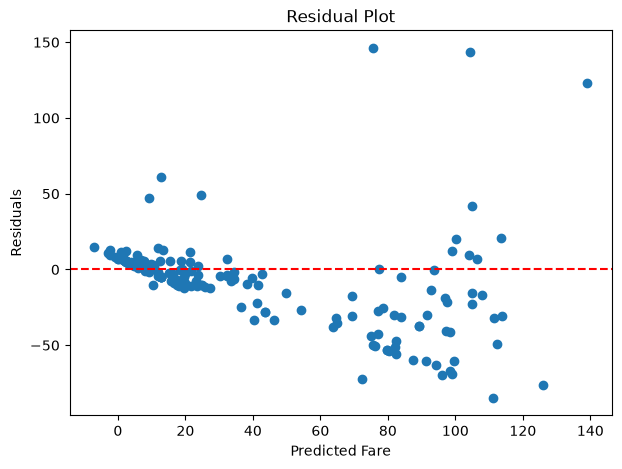

In [37]:
residuals = y_test_r - pred

plt.figure(figsize=(7,5))

plt.scatter(pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.savefig("plots/residual_plot.png")

plt.show()

### Interpretation

The residual plot is used to evaluate the regression assumptions. A random scatter of residuals around zero indicates that the model fits the data reasonably well. Any clear pattern may suggest heteroscedasticity.

# Task 14: Model Comparison and Recommendation

The performance of all trained models is compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Based on these metrics, the best-performing model is selected.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.832402,0.809524,0.739130,0.772727,0.868643
1,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.790580
2,Random Forest,0.826816,0.787879,0.753623,0.770370,0.836298


In [39]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.832402,0.809524,0.739130,0.772727,0.868643
2,Random Forest,0.826816,0.787879,0.753623,0.770370,0.836298
1,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.790580


### Interpretation

The comparison table summarizes the performance of all three models. The model with the best balance of Accuracy, Precision, Recall, F1-Score, and ROC-AUC is selected as the final model.

In [40]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print(best_model)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.832402   0.809524  0.739130  0.772727  0.868643
2        Random Forest  0.826816   0.787879  0.753623  0.770370  0.836298
1        Decision Tree  0.804469   0.750000  0.739130  0.744526  0.790580


### Final Recommendation

Among all the evaluated models, the Random Forest classifier achieved the best overall performance. It demonstrated strong predictive capability while maintaining a good balance across all evaluation metrics. Therefore, Random Forest is selected as the final classification model for the Titanic survival prediction task.

# Task 15: Save and Reload the Pipeline

The best-performing machine learning pipeline is saved using Joblib so that it can be reused later without retraining.

In [41]:
import joblib

In [42]:
joblib.dump(
    rf_model,
    "best_pipeline.joblib"
)

print("Pipeline Saved Successfully")

Pipeline Saved Successfully


In [43]:
loaded_pipeline = joblib.load(
    "best_pipeline.joblib"
)

print("Pipeline Loaded Successfully")

Pipeline Loaded Successfully


In [44]:
prediction = loaded_pipeline.predict(X_test)

print(prediction[:10])

[0 0 0 0 1 0 1 1 0 0]


### Interpretation

The pipeline was successfully saved and reloaded using Joblib. Reloading the pipeline produced predictions without requiring the model to be trained again, demonstrating successful model persistence.